In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [3]:
x = np.load("/content/drive/MyDrive/dataset/csv-5s/X_windows_5s_full_ds.npy")
y_disease = np.load("/content/drive/MyDrive/dataset/csv-5s/Y_disease_5s_labels.npy")
y_activity = np.load("/content/drive/MyDrive/dataset/csv-5s/Y_activity_5s_labels.npy")


In [4]:
print("X shape:", x.shape)
print("Disease labels shape:", y_disease.shape)
print("Activity labels shape:", y_activity.shape)

X shape: (20636, 500, 12)
Disease labels shape: (20636,)
Activity labels shape: (20636,)


In [5]:
X_train, X_temp, y_disease_train, y_disease_temp, y_activity_train, y_activity_temp = train_test_split(x, y_disease, y_activity, test_size=0.3, random_state=42, stratify = y_disease)
print("X_train shape:", X_train.shape)
print("y_disease_train shape:", y_disease_train.shape)
print("y_activity_train shape:", y_activity_train.shape)

X_train shape: (14445, 500, 12)
y_disease_train shape: (14445,)
y_activity_train shape: (14445,)


In [6]:
X_val, X_test, y_disease_val, y_disease_test, y_activity_val, y_activity_test = train_test_split(
    X_temp, y_disease_temp, y_activity_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_disease_temp
)

print("Train shapes:", X_train.shape, y_disease_train.shape, y_activity_train.shape)
print("Val shapes:", X_val.shape, y_disease_val.shape, y_activity_val.shape)
print("Test shapes:", X_test.shape, y_disease_test.shape, y_activity_test.shape)

Train shapes: (14445, 500, 12) (14445,) (14445,)
Val shapes: (3095, 500, 12) (3095,) (3095,)
Test shapes: (3096, 500, 12) (3096,) (3096,)


In [7]:
import numpy as np
from collections import Counter

print("Train disease distribution:", Counter(y_disease_train))
print("Val disease distribution:", Counter(y_disease_val))
print("Test disease distribution:", Counter(y_disease_test))

Train disease distribution: Counter({np.int16(1): 8501, np.int16(2): 3511, np.int16(0): 2433})
Val disease distribution: Counter({np.int16(1): 1821, np.int16(2): 752, np.int16(0): 522})
Test disease distribution: Counter({np.int16(1): 1822, np.int16(2): 753, np.int16(0): 521})


In [8]:
import pandas as pd
(unique, counts) = np.unique(y_disease_train, return_counts=True)
print(pd.DataFrame({'class': unique, 'count': counts}))

   class  count
0      0   2433
1      1   8501
2      2   3511


In [9]:
from sklearn.preprocessing import StandardScaler
N, T, F = X_train.shape
scaler = StandardScaler()
X_train_2d = X_train.reshape(-1, F)
X_val_2d   = X_val.reshape(-1, F)
X_test_2d  = X_test.reshape(-1, F)
scaler.fit(X_train_2d)
X_train_scaled = scaler.transform(X_train_2d).reshape(N, T, F)
X_val_scaled   = scaler.transform(X_val_2d).reshape(X_val.shape[0], T, F)
X_test_scaled  = scaler.transform(X_test_2d).reshape(X_test.shape[0], T, F)


In [10]:
from sklearn.utils.class_weight import compute_class_weight
disease_classes = np.unique(y_disease_train)
disease_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=disease_classes,
    y=y_disease_train
)

# Convert to dictionary: {class_index: weight}
disease_class_weights = {i: w for i, w in zip(disease_classes, disease_weights_array)}
print("Disease class weights:", disease_class_weights)


Disease class weights: {np.int16(0): np.float64(1.9790382244143034), np.int16(1): np.float64(0.5664039524761793), np.int16(2): np.float64(1.3714041583594418)}


In [11]:
print("y_disease_train shape:", y_disease_train.shape)
print("sample_weights[0] shape:", np.array([disease_class_weights[c] for c in y_disease_train]).shape)

print("y_activity_train shape:", y_activity_train.shape)
print("sample_weights[1] shape:", np.ones(len(y_activity_train)).shape)


y_disease_train shape: (14445,)
sample_weights[0] shape: (14445,)
y_activity_train shape: (14445,)
sample_weights[1] shape: (14445,)


In [12]:
import tensorflow as tf
class attention_layer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.W=self.add_weight(name="att_weight", shape=(input_shape[-1],input_shape[-1]), initializer="glorot_uniform", trainable=True)
        self.b=self.add_weight(name="att_bias", shape=(input_shape[-1],), initializer="zeros", trainable=True)
        self.v=self.add_weight(name="att_v", shape=(input_shape[-1],1), initializer="glorot_uniform", trainable=True)
        super().build(input_shape)
    def call(self, inputs, mask=None):
        u = tf.tanh(tf.matmul(inputs,self.W)+self.b)
        scores = tf.matmul(u,self.v)
        alpha = tf.nn.softmax(scores, axis=1)
        context_vector = tf.reduce_sum(inputs*alpha, axis=1)
        return context_vector


In [13]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, LSTM, Dropout, Attention, Permute, Multiply, Lambda, Concatenate, GlobalAveragePooling1D, BatchNormalization

In [14]:
from sklearn.metrics import f1_score
from tensorflow.keras.callbacks import Callback

# Custom callback to compute F1 after each epoch
class F1ScoreCallback(Callback):
    def __init__(self, val_data, batch_size=32):
        super().__init__()
        self.validation_data = val_data
        self.batch_size = batch_size
        self.val_f1s = []

    def on_epoch_end(self, epoch, logs=None):
        X_val, y_val_dict = self.validation_data
        y_true = y_val_dict["disease_output"]

        # Get predictions
        y_pred = self.model.predict(X_val, batch_size=self.batch_size, verbose=0)
        y_pred_classes = np.argmax(y_pred[0], axis=1)  # [0] -> disease_output

        # Compute macro F1
        f1 = f1_score(y_true, y_pred_classes, average="macro")
        self.val_f1s.append(f1)

        print(f"\nEpoch {epoch+1}: val_macro_f1 = {f1:.4f}")
        logs["val_macro_f1"] = f1


In [15]:
f1_callback = F1ScoreCallback(
    val_data=(X_val_scaled, {"disease_output": y_disease_val, "activity_output": y_activity_val}),
    batch_size=64)

In [17]:

def build_multi_task_model(timesteps=100, features=12, num_disease=3, num_activities=10, conv_filter=64, lstm_units=64, dropout_rate=0.3):
    input_layer = tf.keras.layers.Input(shape=(timesteps, features), name="inputs")

    #CNN
    x=layers.Conv1D(conv_filter, kernel_size=7, activation='relu',kernel_regularizer=l2(0.001), padding="same")(input_layer)
    x=layers.BatchNormalization()(x)
    x=layers.Dropout(dropout_rate)(x)
    x=layers.Conv1D(conv_filter, kernel_size=5, activation='relu',kernel_regularizer=l2(0.001), padding="same")(x)
    x=layers.BatchNormalization()(x)
    x=layers.MaxPooling1D(pool_size=2)(x)
    x=layers.Dropout(dropout_rate)(x)

    #BiLSTM
    x=layers.LSTM(lstm_units,kernel_regularizer=l2(0.001), return_sequences=True)(x)
    x=Dropout(0.3)(x)

    #Attention
    atten_out=attention_layer()(x)
    x=Dense(64, activation='relu', kernel_regularizer=l2(0.001))(atten_out)
    x=Dropout(0.3)(x)

    #Disease output
    disease_output = Dense(num_disease, activation='softmax', name='disease_output')(x)

    #Activity output
    activity_output = Dense(num_activities, activation='softmax', name='activity_output')(x)

    model=Model(inputs=input_layer, outputs=[disease_output, activity_output])
    return model

In [18]:
import tensorflow as tf
from tensorflow.keras import backend as K

class MacroF1(tf.keras.metrics.Metric):
    def __init__(self, name="macro_f1", **kwargs):
        super(MacroF1, self).__init__(name=name, **kwargs)
        self.f1 = self.add_weight(name="f1", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.argmax(y_pred, axis=1)

        # Compute F1 using py_function
        f1 = tf.py_function(self._compute_f1, (y_true, y_pred), tf.float32)
        f1.set_shape([])  # <-- FIX: tell TF this is a scalar

        self.f1.assign_add(f1)
        self.count.assign_add(1.0)

    def result(self):
        return self.f1 / self.count

    def reset_states(self):
        self.f1.assign(0.0)
        self.count.assign(0.0)

    def _compute_f1(self, y_true, y_pred):
        from sklearn.metrics import f1_score
        f1 = f1_score(y_true.numpy(), y_pred.numpy(), average="macro")
        return tf.constant(f1, dtype=tf.float32)  # <-- FIX

In [21]:
input_shape = (X_train.shape[1], X_train.shape[2])
num_disease = len(np.unique(y_disease_train))
num_activities = len(np.unique(y_activity_train))

model = build_multi_task_model(timesteps=input_shape[0], features=input_shape[1], num_disease=num_disease, num_activities=num_activities)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={
        'disease_output': 'sparse_categorical_crossentropy',
        'activity_output': 'sparse_categorical_crossentropy'
    },
    metrics={
        "disease_output": ["accuracy", MacroF1(name="macro_f1")],
        'activity_output': 'accuracy'
    }
)

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint_path = "/content/checkpoints/epoch_{epoch:02d}_val_loss_{val_loss:.4f}.h5"

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,   # save full model (set True if only weights needed)
    save_freq="epoch",         # save at every epoch
    monitor="val_loss",        # metric to monitor
    save_best_only=False,      # False → save all epochs
    verbose=1
)

In [22]:
history = model.fit(
    X_train_scaled,
    [y_disease_train, y_activity_train],   # <-- list, not dict
    validation_data = (
        X_val_scaled,
        [y_disease_val, y_activity_val]    # <-- also list
    ),
    epochs=100,
    batch_size=64,
    sample_weight=[
        np.array([disease_class_weights[c] for c in y_disease_train]),  # weights for disease_output
        np.ones(len(y_activity_train))                                  # weights for activity_output
    ],
    callbacks=[checkpoint_callback, f1_callback]
)

Epoch 1/100
225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - activity_output_accuracy: 0.5239 - activity_output_loss: 1.5064 - disease_output_accuracy: 0.3565 - disease_output_loss: 1.1302 - disease_output_macro_f1: 0.3252 - loss: 2.8739
Epoch 1: saving model to /content/checkpoints/epoch_01_val_loss_3.1129.h5



Epoch 1: val_macro_f1 = 0.3569
226/226 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - activity_output_accuracy: 0.5249 - activity_output_loss: 1.5034 - disease_output_accuracy: 0.3566 - disease_output_loss: 1.1301 - disease_output_macro_f1: 0.3253 - loss: 2.8708 - val_activity_output_accuracy: 0.5389 - val_activity_output_loss: 1.8429 - val_disease_output_accuracy: 0.3845 - val_disease_output_loss: 1.0553 - val_disease_output_macro_f1: 0.3518 - val_loss: 3.1129 - val_macro_f1: 0.3569
Epoch 2/100
224/226 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - activity_output_accuracy: 0.7523 - activity_output_loss: 0.7835 - disease_output_accuracy: 0.3786 - disease_output_loss: 1.0873 - disease_output_macro_f1: 0.3539 - loss: 2.0778
Epoch 2: saving model to /content/checkpoints/epoch_02_val_loss_2.0997.h5



Epoch 2: val_macro_f1 = 0.3943
226/226 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - activity_output_accuracy: 0.7524 - activity_output_loss: 0.7831 - disease_output_accuracy: 0.3785 - disease_output_loss: 1.0873 - disease_output_macro_f1: 0.3539 - loss: 2.0772 - val_activity_output_accuracy: 0.6420 - val_activity_output_loss: 0.8903 - val_disease_output_accuracy: 0.4388 - val_disease_output_loss: 1.0168 - val_disease_output_macro_f1: 0.3892 - val_loss: 2.0997 - val_macro_f1: 0.3943
Epoch 3/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - activity_output_accuracy: 0.7951 - activity_output_loss: 0.6417 - disease_output_accuracy: 0.3730 - disease_output_loss: 1.0523 - disease_output_macro_f1: 0.3579 - loss: 1.8811
Epoch 3: saving model to /content/checkpoints/epoch_03_val_loss_1.7417.h5



Epoch 3: val_macro_f1 = 0.3990
226/226 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - activity_output_accuracy: 0.7951 - activity_output_loss: 0.6417 - disease_output_accuracy: 0.3730 - disease_output_loss: 1.0523 - disease_output_macro_f1: 0.3579 - loss: 1.8811 - val_activity_output_accuracy: 0.8171 - val_activity_output_loss: 0.5417 - val_disease_output_accuracy: 0.4155 - val_disease_output_loss: 1.0234 - val_disease_output_macro_f1: 0.3908 - val_loss: 1.7417 - val_macro_f1: 0.3990
Epoch 4/100
225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - activity_output_accuracy: 0.8155 - activity_output_loss: 0.5629 - disease_output_accuracy: 0.3953 - disease_output_loss: 1.0363 - disease_output_macro_f1: 0.3741 - loss: 1.7727
Epoch 4: saving model to /content/checkpoints/epoch_04_val_loss_1.7564.h5



Epoch 4: val_macro_f1 = 0.3693
226/226 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - activity_output_accuracy: 0.8156 - activity_output_loss: 0.5628 - disease_output_accuracy: 0.3953 - disease_output_loss: 1.0364 - disease_output_macro_f1: 0.3741 - loss: 1.7726 - val_activity_output_accuracy: 0.8142 - val_activity_output_loss: 0.5445 - val_disease_output_accuracy: 0.3742 - val_disease_output_loss: 1.0486 - val_disease_output_macro_f1: 0.3646 - val_loss: 1.7564 - val_macro_f1: 0.3693
Epoch 5/100
225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - activity_output_accuracy: 0.8399 - activity_output_loss: 0.5022 - disease_output_accuracy: 0.3883 - disease_output_loss: 1.0345 - disease_output_macro_f1: 0.3745 - loss: 1.7007
Epoch 5: saving model to /content/checkpoints/epoch_05_val_loss_1.7625.h5


...


Epoch 96: val_macro_f1 = 0.6017
226/226 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - activity_output_accuracy: 0.9554 - activity_output_loss: 0.1370 - disease_output_accuracy: 0.6524 - disease_output_loss: 0.6488 - disease_output_macro_f1: 0.6361 - loss: 0.9705 - val_activity_output_accuracy: 0.9522 - val_activity_output_loss: 0.1663 - val_disease_output_accuracy: 0.6197 - val_disease_output_loss: 0.7853 - val_disease_output_macro_f1: 0.5955 - val_loss: 1.1382 - val_macro_f1: 0.6017
Epoch 97/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - activity_output_accuracy: 0.9546 - activity_output_loss: 0.1348 - disease_output_accuracy: 0.6622 - disease_output_loss: 0.6271 - disease_output_macro_f1: 0.6452 - loss: 0.9456
Epoch 97: saving model to /content/checkpoints/epoch_97_val_loss_1.1955.h5



Epoch 97: val_macro_f1 = 0.5894
226/226 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - activity_output_accuracy: 0.9546 - activity_output_loss: 0.1349 - disease_output_accuracy: 0.6622 - disease_output_loss: 0.6272 - disease_output_macro_f1: 0.6452 - loss: 0.9457 - val_activity_output_accuracy: 0.9405 - val_activity_output_loss: 0.2007 - val_disease_output_accuracy: 0.6100 - val_disease_output_loss: 0.8119 - val_disease_output_macro_f1: 0.5849 - val_loss: 1.1955 - val_macro_f1: 0.5894
Epoch 98/100
225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - activity_output_accuracy: 0.9564 - activity_output_loss: 0.1322 - disease_output_accuracy: 0.6694 - disease_output_loss: 0.6251 - disease_output_macro_f1: 0.6498 - loss: 0.9414
Epoch 98: saving model to /content/checkpoints/epoch_98_val_loss_1.2001.h5



Epoch 98: val_macro_f1 = 0.5846
226/226 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - activity_output_accuracy: 0.9564 - activity_output_loss: 0.1322 - disease_output_accuracy: 0.6693 - disease_output_loss: 0.6252 - disease_output_macro_f1: 0.6497 - loss: 0.9415 - val_activity_output_accuracy: 0.9522 - val_activity_output_loss: 0.1707 - val_disease_output_accuracy: 0.5974 - val_disease_output_loss: 0.8508 - val_disease_output_macro_f1: 0.5773 - val_loss: 1.2001 - val_macro_f1: 0.5846
Epoch 99/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - activity_output_accuracy: 0.9557 - activity_output_loss: 0.1376 - disease_output_accuracy: 0.6586 - disease_output_loss: 0.6189 - disease_output_macro_f1: 0.6390 - loss: 0.9398
Epoch 99: saving model to /content/checkpoints/epoch_99_val_loss_1.1831.h5



Epoch 99: val_macro_f1 = 0.5887
226/226 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - activity_output_accuracy: 0.9557 - activity_output_loss: 0.1376 - disease_output_accuracy: 0.6586 - disease_output_loss: 0.6189 - disease_output_macro_f1: 0.6390 - loss: 0.9398 - val_activity_output_accuracy: 0.9422 - val_activity_output_loss: 0.1896 - val_disease_output_accuracy: 0.6239 - val_disease_output_loss: 0.8101 - val_disease_output_macro_f1: 0.5833 - val_loss: 1.1831 - val_macro_f1: 0.5887
Epoch 100/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - activity_output_accuracy: 0.9566 - activity_output_loss: 0.1376 - disease_output_accuracy: 0.6662 - disease_output_loss: 0.6126 - disease_output_macro_f1: 0.6494 - loss: 0.9341
Epoch 100: saving model to /content/checkpoints/epoch_100_val_loss_1.2021.h5



Epoch 100: val_macro_f1 = 0.5788
226/226 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - activity_output_accuracy: 0.9566 - activity_output_loss: 0.1376 - disease_output_accuracy: 0.6662 - disease_output_loss: 0.6126 - disease_output_macro_f1: 0.6494 - loss: 0.9341 - val_activity_output_accuracy: 0.9402 - val_activity_output_loss: 0.1865 - val_disease_output_accuracy: 0.5974 - val_disease_output_loss: 0.8305 - val_disease_output_macro_f1: 0.5735 - val_loss: 1.2021 - val_macro_f1: 0.5788


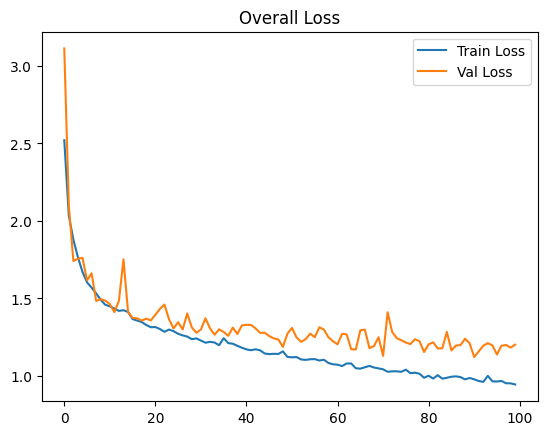

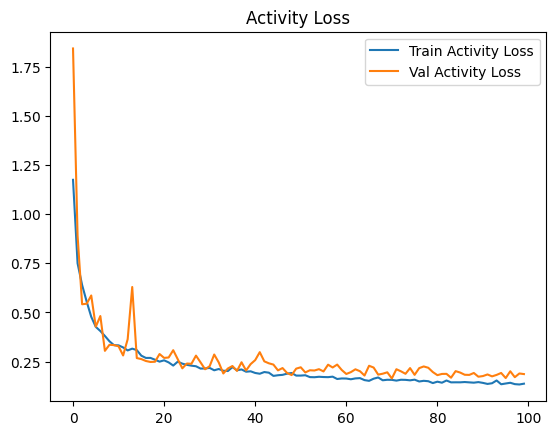

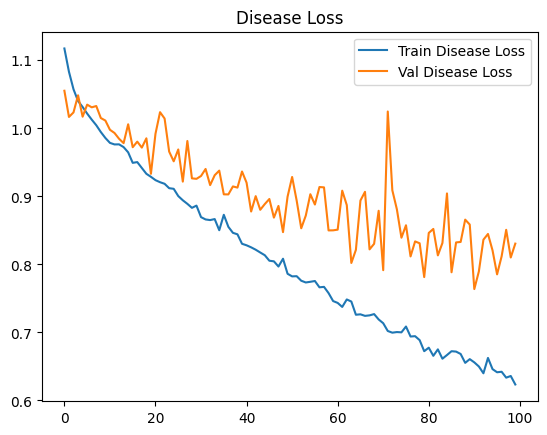

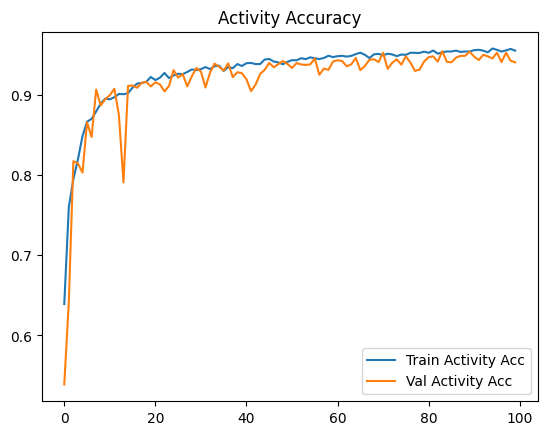

In [24]:
import matplotlib.pyplot as plt

# ---- Plot overall loss ----
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Overall Loss")
plt.show()

# ---- Plot activity loss ----
plt.plot(history.history["activity_output_loss"], label="Train Activity Loss")
plt.plot(history.history["val_activity_output_loss"], label="Val Activity Loss")
plt.legend()
plt.title("Activity Loss")
plt.show()

# ---- Plot disease loss ----
plt.plot(history.history["disease_output_loss"], label="Train Disease Loss")
plt.plot(history.history["val_disease_output_loss"], label="Val Disease Loss")
plt.legend()
plt.title("Disease Loss")
plt.show()

# ---- Plot activity accuracy ----
plt.plot(history.history["activity_output_accuracy"], label="Train Activity Acc")
plt.plot(history.history["val_activity_output_accuracy"], label="Val Activity Acc")
plt.legend()
plt.title("Activity Accuracy")
plt.show()


In [25]:
import numpy as np
print("Train disease distribution:", np.bincount(y_disease_train))
print("Test disease distribution:", np.bincount(y_disease_test))
print("Train activity distribution:", np.bincount(y_activity_train))
print("Test activity distribution:", np.bincount(y_activity_test))


Train disease distribution: [2433 8501 3511]
Test disease distribution: [ 521 1822  753]
Train activity distribution: [ 977  968 3262  976 1007  973 3343  968  985  986]
Test activity distribution: [214 218 709 221 199 223 653 222 219 218]


97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Disease Classification Report:
              precision    recall  f1-score   support

   Disease_0     0.3830    0.8580    0.5296       521
   Disease_1     0.7991    0.5719    0.6667      1822
   Disease_2     0.5792    0.4807    0.5254       753

    accuracy                         0.5979      3096
   macro avg     0.5871    0.6369    0.5739      3096
weighted avg     0.6756    0.5979    0.6092      3096



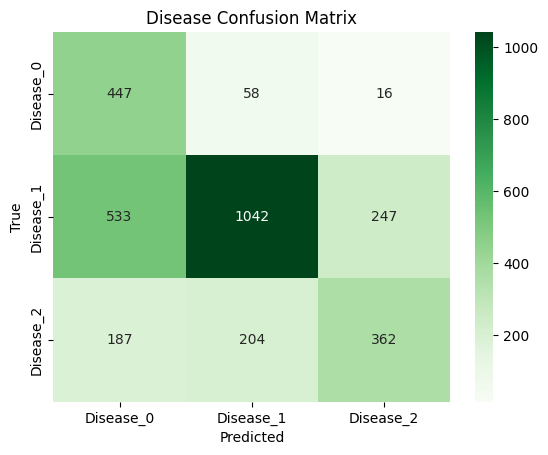


Activity Classification Report:
              precision    recall  f1-score   support

  Activity_0     0.8564    0.7804    0.8166       214
  Activity_1     0.9659    0.9083    0.9362       218
  Activity_2     0.9818    0.9887    0.9852       709
  Activity_3     1.0000    0.9367    0.9673       221
  Activity_4     0.7907    0.8543    0.8213       199
  Activity_5     0.9817    0.9641    0.9729       223
  Activity_6     0.9848    0.9923    0.9886       653
  Activity_7     0.8066    0.8829    0.8430       222
  Activity_8     0.9070    0.8904    0.8986       219
  Activity_9     0.9556    0.9862    0.9707       218

    accuracy                         0.9406      3096
   macro avg     0.9230    0.9184    0.9200      3096
weighted avg     0.9419    0.9406    0.9408      3096



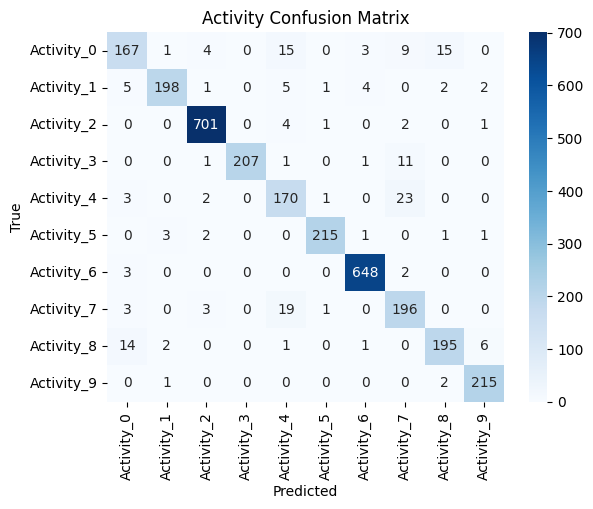

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ---- Predictions ----
y_pred_test = model.predict(X_test_scaled)

y_pred_disease = np.argmax(y_pred_test[0], axis=1)
y_pred_activity = np.argmax(y_pred_test[1], axis=1)

# ---- Disease Report ----
print("\nDisease Classification Report:")
print(classification_report(y_disease_test, y_pred_disease, target_names=[f"Disease_{i}" for i in range(3)], digits=4))

cm_disease = confusion_matrix(y_disease_test, y_pred_disease)
sns.heatmap(cm_disease, annot=True, fmt="d", cmap="Greens",
            xticklabels=[f"Disease_{i}" for i in range(3)],
            yticklabels=[f"Disease_{i}" for i in range(3)])
plt.title("Disease Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---- Activity Report ----
print("\nActivity Classification Report:")
print(classification_report(y_activity_test, y_pred_activity, target_names=[f"Activity_{i}" for i in range(10)], digits=4))

cm_activity = confusion_matrix(y_activity_test, y_pred_activity)
sns.heatmap(cm_activity, annot=True, fmt="d", cmap="Blues",
            xticklabels=[f"Activity_{i}" for i in range(10)],
            yticklabels=[f"Activity_{i}" for i in range(10)])
plt.title("Activity Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
